<a href="https://colab.research.google.com/github/AngelikaBaloy/undergrad_ml_assignments/blob/main/demand_est_project/Demand_est_strategy3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers
Angelika Baloy

### Notebook 3: Strategy: Costs, Markups, and Profit

In [1]:
! git clone https://github.com/AngelikaBaloy/undergrad_ml_assignments/

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 307, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 307 (delta 31), reused 18 (delta 18), pack-reused 270 (from 5)
Receiving objects: 100% (307/307), 20.78 MiB | 1.83 MiB/s, done.
Resolving deltas: 100% (133/133), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
# loading in data
df = pd.read_csv('undergrad_ml_assignments/demand_est_project/air_fryers_clean_brand_year.csv')

In [4]:
# dummies

brand_dummies = pd.get_dummies(df['brand'], drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str), drop_first=True, dtype=int)
# 2019 and chefman dropped

In [5]:
y = df['log_brand_share']

feature_list = ['compact_share', 'dual_basket_share','oven_style_share', 'rotisserie_share', 'window_share']

X = pd.concat(
    [df[["avg_price", "avg_rating"] + feature_list], brand_dummies, year_dummies],
    axis=1,)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_})

print("R-squared:", r2)
coef_table

R-squared: 0.763453950091436


,feature,coefficient
0,avg_price,-0.037668
1,avg_rating,0.287517
2,compact_share,9.815304
3,dual_basket_share,-9.509686
4,oven_style_share,1.941774
5,rotisserie_share,-5.674054
6,window_share,12.880298
7,cosori,2.551946
8,cuisinart,6.422436
9,dash,0.176655


Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

In [7]:
# computation
price_coef = coef_table.loc[coef_table["feature"] == "avg_price", "coefficient"].iloc[0]
print("Estimated price coefficient:", price_coef)

results = df.copy()
results["predicted_log_share"] = predicted_log_share
results["demand_slope"] = price_coef * results["brand_share"] * (1 - results["brand_share"])
results["unit_cost"] = results["avg_price"] + results["brand_share"] / results["demand_slope"]
results["markup"] = results["avg_price"] - results["unit_cost"]
results["average_profit"] = results["brand_share"] * results["markup"]
results["profit_derivative"] = (
    results["demand_slope"] * results["markup"] + results["brand_share"]
)

print(results[["unit_cost", "markup", "average_profit", "profit_derivative"]].describe())

Estimated price coefficient: -0.03766765298429383
        unit_cost     markup  average_profit  profit_derivative
count   50.000000  50.000000       50.000000       5.000000e+01
mean    93.102239  29.703894        3.155916       2.985893e-18
std     51.696080   2.615822        2.615822       1.753363e-17
min     22.002913  26.567362        0.019385      -2.775558e-17
25%     53.159061  27.952365        1.404387      -3.903128e-18
50%     70.038270  28.813285        2.265308       0.000000e+00
75%    123.561937  30.956852        4.408875       1.214306e-17
max    199.729962  37.507010       10.959033       5.551115e-17


In [8]:
# results by brand
results[[
    'brand',
    'markup',
    'unit_cost',
    'average_profit'
]].groupby('brand').mean()

,markup,unit_cost,average_profit
brand,,,
chefman,29.368946,61.569466,2.820968
cosori,27.984628,86.283321,1.436651
cuisinart,29.050974,194.896119,2.502997
dash,29.542349,27.936578,2.994372
gowise usa,31.153741,56.301040,4.605764
instant_pot,32.558234,71.903119,6.010256
ninja,32.854071,112.488470,6.306093
nuwave,27.970835,109.053549,1.422858
oster,27.226315,161.804969,0.678338


1. What are the average unit costs and markups for each brand over the years?
* The code chunk below shows the average unit costs and markups for each brand across all years. Across all brands, markups are relatively similar, ranging from 27 to 32 dollars. Unit costs are more varied.

In [21]:
# average unit costs & markups per brand across all years

cost_markups = results[[
    'brand',
    'unit_cost',
    'markup'
]].groupby('brand').mean()
cost_markups

,unit_cost,markup
brand,,
chefman,61.569466,29.368946
cosori,86.283321,27.984628
cuisinart,194.896119,29.050974
dash,27.936578,29.542349
gowise usa,56.301040,31.153741
instant_pot,71.903119,32.558234
ninja,112.488470,32.854071
nuwave,109.053549,27.970835
oster,161.804969,27.226315


2. Are any inferred unit costs negative? If so, what might that mean?
* No inferred unit costs are negative. If a unit cost was negative, producing more products would not cost the brand anything, which makes little sense.

3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatterplots of price vs. unit cost and average rating vs. unit cost. Do more expensive products have higher consumer satisfaction?

* Cuisinart, Oster, Ninja, and Nuwave have the higest unit costs, ranging from 194.90 to 109.05.
* All of these brands are highly rated (4.3+) yet the unit costs are more varied. A higher unit cost does not seem to be an indicator of a more highly rated product.
* More expensive products do not have higher consumer satisfaction. The highest rated air fryers appear to be in the middle range of prices (not the cheapest nor the most expensive).

In [16]:
# highest unit costs

unit_cost_brand = results[[
    'brand',
    'unit_cost'
]].groupby('brand').mean().sort_values(by='unit_cost', ascending=False)

unit_cost_brand = pd.DataFrame(unit_cost_brand)
unit_cost_brand

,unit_cost
brand,
cuisinart,194.896119
oster,161.804969
ninja,112.488470
nuwave,109.053549
cosori,86.283321
instant_pot,71.903119
chefman,61.569466
gowise usa,56.301040
ultrean,48.785765


In [15]:
# avg ratings

ratings_brand = pd.DataFrame(df['avg_rating'].groupby(df['brand']).mean())
ratings_brand

,avg_rating
brand,
chefman,4.427966
cosori,4.656292
cuisinart,4.438892
dash,4.476394
gowise usa,4.576990
instant_pot,4.559323
ninja,4.742064
nuwave,4.389798
oster,4.388653


In [17]:
# unit costs & ratings
unit_costs_n_ratings = pd.merge(unit_cost_brand, ratings_brand, on='brand')
unit_costs_n_ratings

,unit_cost,avg_rating
brand,,
cuisinart,194.896119,4.438892
oster,161.804969,4.388653
ninja,112.488470,4.742064
nuwave,109.053549,4.389798
cosori,86.283321,4.656292
instant_pot,71.903119,4.559323
chefman,61.569466,4.427966
gowise usa,56.301040,4.576990
ultrean,48.785765,4.672616


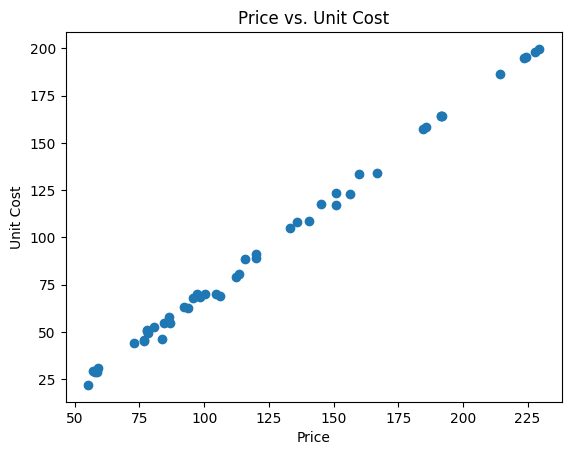

In [27]:
# price vs. unit cost

plt.scatter(df['avg_price'], results['unit_cost'])
plt.xlabel('Price')
plt.ylabel('Unit Cost')
plt.title('Price vs. Unit Cost')
plt.show()


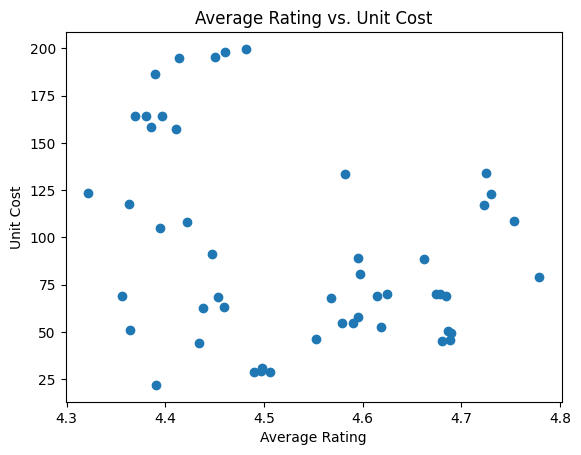

In [28]:
# avg rating vs. cost

plt.scatter(df['avg_rating'], results['unit_cost'])
plt.xlabel('Average Rating')
plt.ylabel('Unit Cost')
plt.title('Average Rating vs. Unit Cost')
plt.show()

4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.

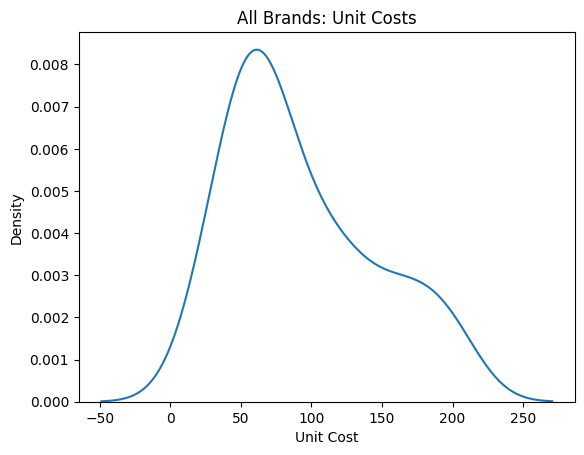

In [31]:
# kdeplot of unit costs (general)

sns.kdeplot(results['unit_cost'])
plt.xlabel('Unit Cost')
plt.ylabel('Density')
plt.title('All Brands: Unit Costs')
plt.show()


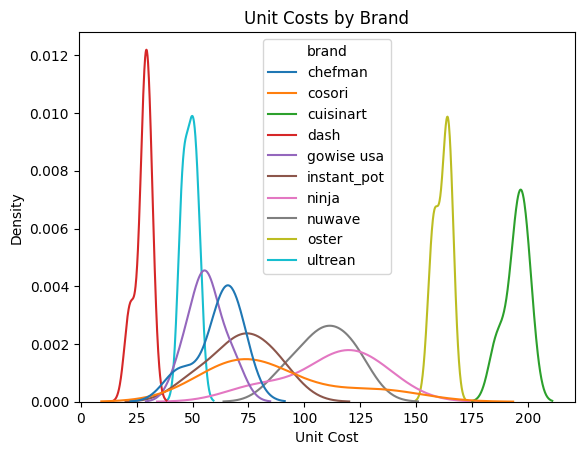

In [30]:
# kdeplot of unit costs (hued by brand)

sns.kdeplot(data=results, x='unit_cost', hue='brand')
plt.xlabel('Unit Cost')
plt.ylabel('Density')
plt.title('Unit Costs by Brand')
plt.show()

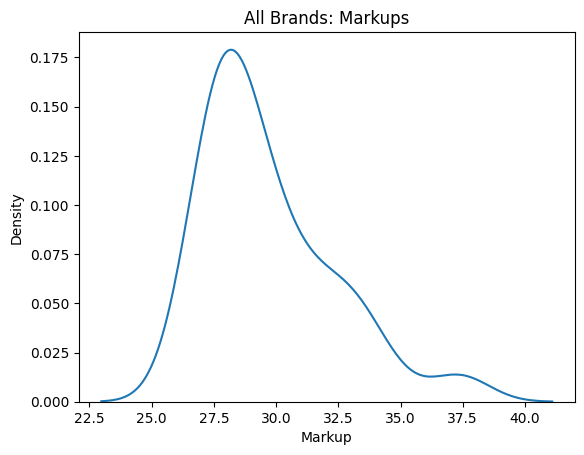

In [32]:
# kdeplot of markups (general)

sns.kdeplot(results['markup'])
plt.xlabel('Markup')
plt.ylabel('Density')
plt.title('All Brands: Markups')
plt.show()

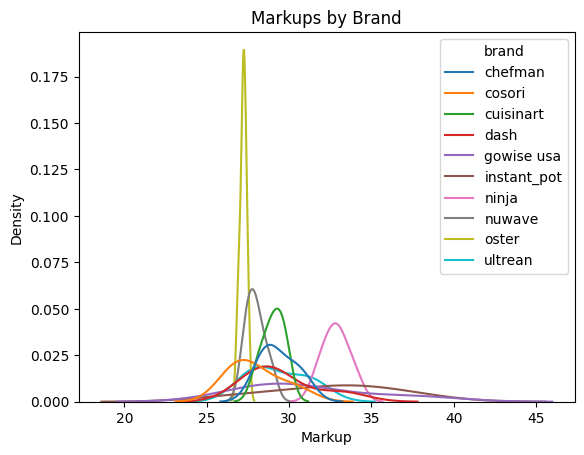

In [33]:
# kdeplot of markups (by brand)

sns.kdeplot(data=results, x='markup', hue='brand')
plt.xlabel('Markup')
plt.ylabel('Density')
plt.title('Markups by Brand')
plt.show()

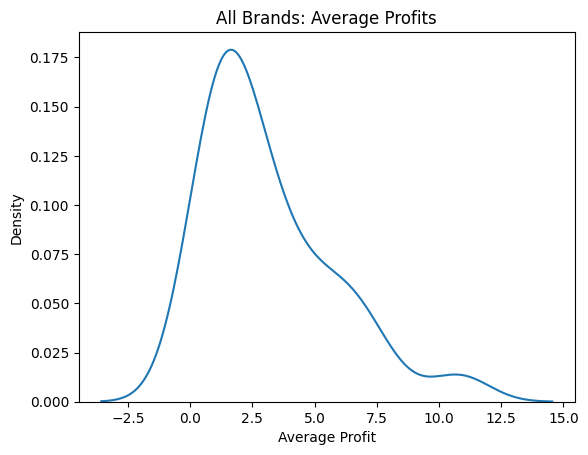

In [34]:
# kdeplot of profit (general)

sns.kdeplot(results['average_profit'])
plt.xlabel('Average Profit')
plt.ylabel('Density')
plt.title('All Brands: Average Profits')
plt.show()

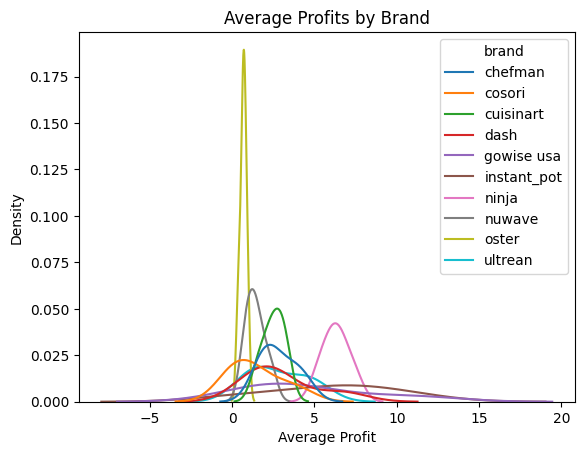

In [35]:
# kdeplot of profit (by brand)

sns.kdeplot(data=results, x='average_profit', hue='brand')
plt.xlabel('Average Profit')
plt.ylabel('Density')
plt.title('Average Profits by Brand')
plt.show()

5. Which brands have the highest share-weighted average profit?
* Ninja, Instant pot, and Gowise seem to be the most profitable. The kdeplot above shows that average profit within a single brand can have a large spread.

In [36]:
# avg profit

avg_profit_brand = results[[
    'brand',
    'average_profit'
]].groupby('brand').mean().sort_values(by='average_profit', ascending=False)

avg_profit_brand

,average_profit
brand,
ninja,6.306093
instant_pot,6.010256
gowise usa,4.605764
dash,2.994372
chefman,2.820968
ultrean,2.780864
cuisinart,2.502997
cosori,1.436651
nuwave,1.422858
